<a href="https://colab.research.google.com/github/diazveraserrano-boop/-Deep-Learning-Based-Automated-Cell-Viability-Analysis-/blob/main/Final_Segmentations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# BLOCK 1: Installations and libraries
!pip install -q opencv-python-headless scikit-learn matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from google.colab import files
import os

In [2]:
# BLOCK 2: Upload the image
print("Upload your image:")
uploaded = files.upload()

# Take the uploaded file
filename = list(uploaded.keys())[0]

# Split base name and extension
base_name, extension = os.path.splitext(filename)

# Output name: same base name + _ask + extension
output_filename = f"{base_name}_ask{extension}"

img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"Image loaded: {img.shape}")
print(f"Output filename will be: {output_filename}")

Upload your image:


Saving Image1mask.jpg to Image1mask.jpg
Image loaded: (2048, 2048, 3)
Output filename will be: Image1mask_ask.jpg


In [3]:
# BLOCK 3: Clustering
h, w, _ = img.shape
pixels = img.reshape(-1, 3).astype(np.float32)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(pixels)

labels = kmeans.labels_
centers = kmeans.cluster_centers_.astype(np.uint8)

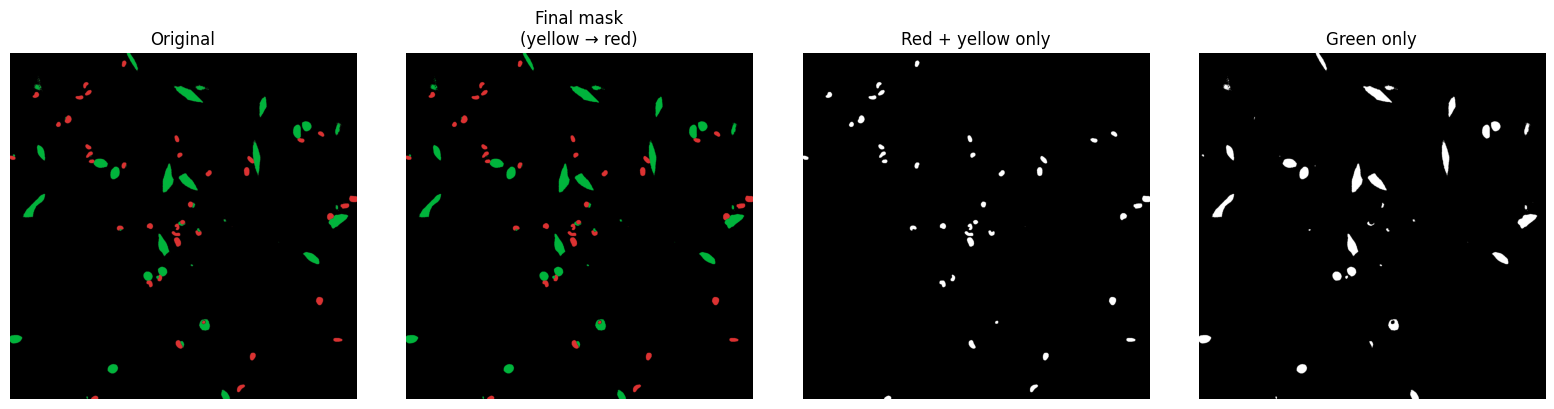

In [4]:
# BLOCK 4: HSV detection with expanded red range to capture yellow as red

hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

# Red + yellow-orange (expanded to include Hue ~0–40°)
# This makes pure yellow be considered "red" in the mask
lower_red1 = np.array([0,   60,  50])      # Hue 0° → lower saturation and value thresholds
upper_red1 = np.array([40,  255, 255])     # ← key change: up to 40° (yellow-orange)

lower_red2 = np.array([160, 60,  50])      # red-magenta
upper_red2 = np.array([180, 255, 255])

mask_rojo = cv2.inRange(hsv, lower_red1, upper_red1) | \
            cv2.inRange(hsv, lower_red2, upper_red2)

# Green (adjusted to avoid too much overlap with the new red range)
lower_green = np.array([45,  60,  50])     # start at 45° to leave space for yellow
upper_green = np.array([90,  255, 255])
mask_verde = cv2.inRange(hsv, lower_green, upper_green)

# Background = everything outside red and green
mask_fondo = cv2.bitwise_not(mask_rojo | mask_verde)

# Absolute priority to red (yellow → red)
mask_final = np.zeros_like(mask_verde, dtype=np.uint8)
mask_final[mask_rojo > 0] = 2                          # red (includes yellow)
mask_final[(mask_verde > 0) & (mask_rojo == 0)] = 1    # pure green only
mask_final[(mask_rojo == 0) & (mask_verde == 0)] = 0   # background

# Build final masked image
mask_rgb = np.zeros_like(img, dtype=np.uint8)
mask_rgb[mask_final == 1] = [0,   180,  60]   # green
mask_rgb[mask_final == 2] = [220,  50,  50]   # red (includes yellow)
mask_rgb[mask_final == 0] = [0,     0,   0]   # black

# Visualization to verify
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(mask_rgb)
axes[1].set_title("Final mask\n(yellow → red)")
axes[1].axis('off')

axes[2].imshow(mask_rojo, cmap='gray')
axes[2].set_title("Red + yellow only")
axes[2].axis('off')

axes[3].imshow(mask_verde, cmap='gray')
axes[3].set_title("Green only")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# BLOCK 5: Save the mask and download it automatically

# Output filename: original base name + _ask + extension
base_name, extension = os.path.splitext(filename)
output_filename = f"{base_name}_ask{extension}"

# Save the image in BGR format (required by cv2.imwrite)
cv2.imwrite(output_filename, cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2BGR))

print(f"Mask saved as: {output_filename}")
print(f"Saved image size: {mask_rgb.shape}")

# Automatic download
files.download(output_filename)

Mask saved as: Image1mask_ask.jpg
Saved image size: (2048, 2048, 3)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>